In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_clean = pd.read_csv("Clean-Data")
df_clean

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,193,0,92,0,285.0
1,2023-01-01 01:00:00,153,0,49,0,202.0
2,2023-01-01 02:00:00,110,0,33,0,143.0
3,2023-01-01 03:00:00,198,0,61,0,259.0
4,2023-01-01 04:00:00,155,0,77,0,232.0
...,...,...,...,...,...,...
4316,2023-06-29 20:00:00,0,1450,54,0,1504.0
4317,2023-06-29 21:00:00,95,2059,78,0,2232.0
4318,2023-06-29 22:00:00,110,1655,36,0,1801.0
4319,2023-06-29 23:00:00,78,2497,79,1035,3689.0


In [3]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean.set_index('timestamp', inplace=True)

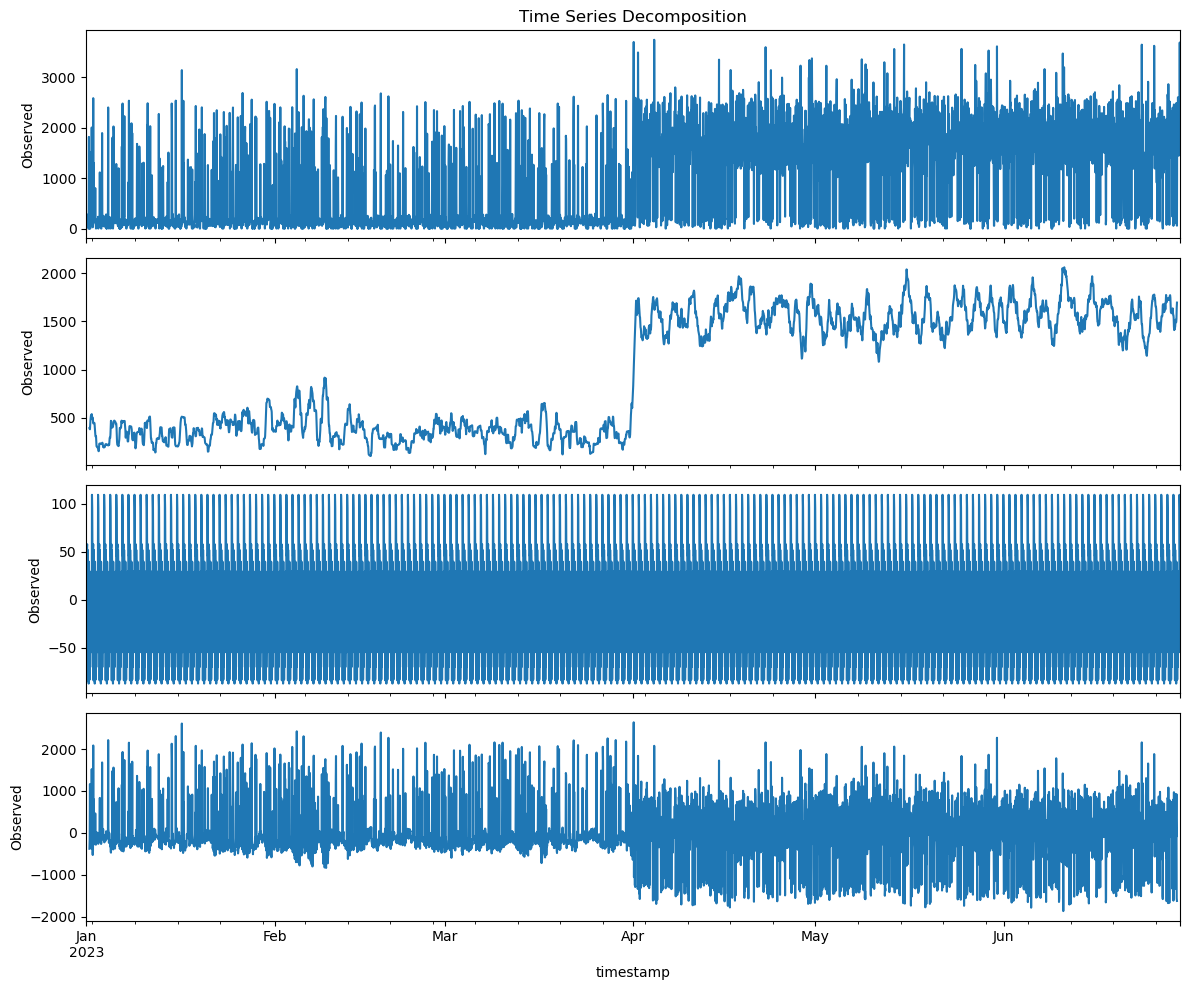

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

target_col = df_clean['total_power']

# Y(t) = Trend(t) + Seasonality(t) + Residual(t)
decomposition = seasonal_decompose(df_clean['total_power'], model = 'additive', period = 24)

decomposition

fig, (ax1,ax2,ax3,ax4) = plt.subplots(4,1, figsize=(12,10),sharex=True)

decomposition.observed.plot(ax=ax1)
ax1.set_ylabel("Observed")
ax1.set_title("Time Series Decomposition")

decomposition.trend.plot(ax=ax2)
ax2.set_ylabel("Observed")
# ax1.set_title("Time Series Decomposition")

decomposition.seasonal.plot(ax=ax3)
ax3.set_ylabel("Observed")
# ax1.set_title("Time Series Decomposition")

decomposition.resid.plot(ax=ax4)
ax4.set_ylabel("Observed")
# ax1.set_title("Time Series Decomposition")

plt.tight_layout()
plt.show()

In [4]:
df_clean['day'] = df_clean.index.day_name()

weekday = df_clean[df_clean['day'].isin(['Monday','Tuesday','Wednesday','Thursday','Friday'])]
weekend = df_clean[df_clean['day'].isin(['Saturday','Sunday'])]

print("Weekday Average:", weekday['total_power'].mean())
print("Weekend Average:", weekend['total_power'].mean())

Weekday Average: 967.9392960929932
Weekend Average: 958.6968954248366


C:\Users\louis\AppData\Local\Temp\ipykernel_17552\3756451918.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_clean['total_power'].resample('M').mean()


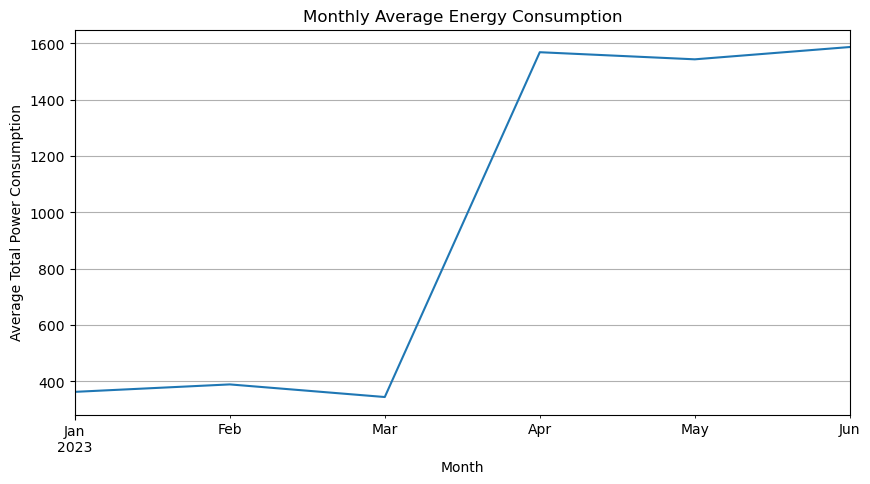

In [5]:
monthly = df_clean['total_power'].resample('M').mean()
monthly.plot(figsize=(10,5))
plt.title("Monthly Average Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Average Total Power Consumption")
plt.grid(True)
plt.show()

In [6]:
target_col = 'total_power'

skewness =  df_clean[target_col].skew()
kurtosis = df_clean[target_col].kurtosis()

print(f"skewness of {target_col}: {skewness:.4f}")
print(f"kurtosis of {target_col}: {kurtosis:.4f}")

skewness of total_power: 0.4654
kurtosis of total_power: -1.2739


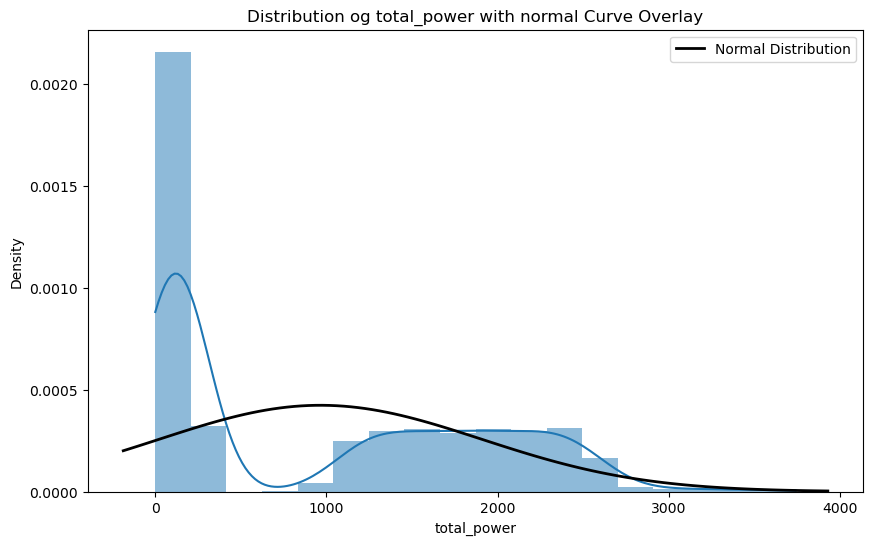

In [7]:
from scipy import stats
plt.figure(figsize=(10,6))
sns.histplot(df_clean[target_col],kde = True, stat="density",linewidth=0)
#Overlay the normal distribution for comparision

xmin,xmax = plt.xlim()
x = np.linspace(xmin,xmax,100)
p = stats.norm.pdf(x, df_clean[target_col].mean(),df_clean[target_col].std())
plt.plot(x,p,'k',linewidth = 2,label = 'Normal Distribution')
plt.title(f'Distribution og {target_col} with normal Curve Overlay')
plt.legend()
plt.show()

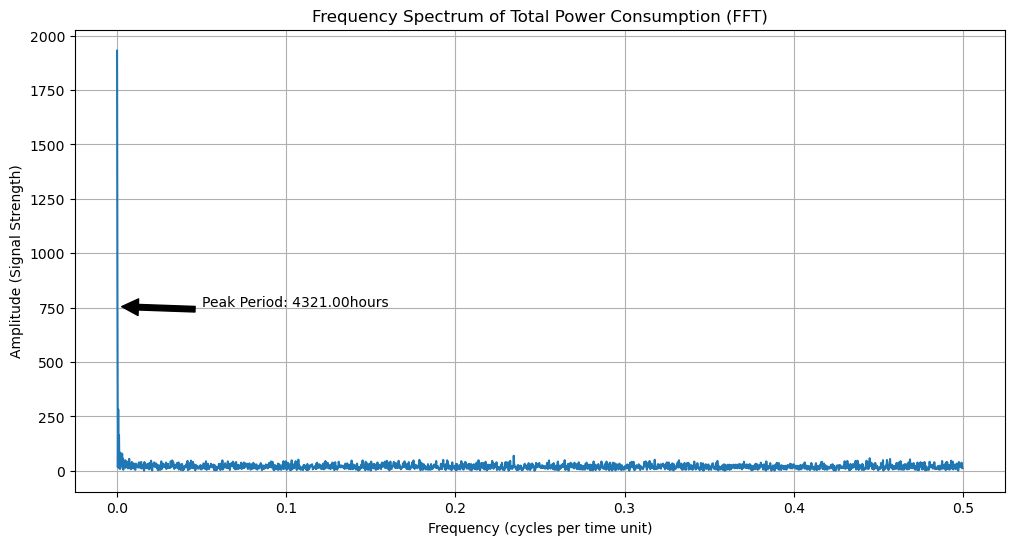

array([0.00000000e+00, 2.31427910e-04, 4.62855820e-04, ...,
       4.99190002e-01, 4.99421430e-01, 4.99652858e-01], shape=(2160,))

In [8]:
from scipy.fft import fft,fftfreq

y = df_clean[target_col].values
N = len(y)
# T = 1.0/24.0


yf = fft(y)
xf = fftfreq(N,1)

xf_pos = xf[:N//2]
yf_pos = 2.0/N * np.abs(yf[0:N//2])

plt.figure(figsize = (12,6))
plt.plot(xf_pos,yf_pos)
plt.title("Frequency Spectrum of Total Power Consumption (FFT)")
plt.xlabel("Frequency (cycles per time unit)")
plt.ylabel("Amplitude (Signal Strength)")
plt.grid(True)

peak_idx = np.argmax( yf_pos[1:]) + 1
peak_freq = xf_pos[peak_idx]

period = 1/peak_freq
plt.annotate(f'Peak Period: {period:.2f}hours',
             xy = (peak_freq, yf_pos[peak_idx]),
            xytext = (peak_freq+0.05, yf_pos[peak_idx]),
    arrowprops=dict(facecolor='black',shrink=0.05))
plt.show()
xf_pos

In [9]:
seasonal_strength = decomposition.seasonal.var() / df_clean['total_power'].var()
print("Seasonal Strength:", seasonal_strength)

Seasonal Strength: 0.0036966980900151403


In [10]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    
    if result[1] <= 0.05:
        print("Data is Stationary")
    else:
        print("Data is Non-Stationary")

adf_test(df_clean['total_power'])

ADF Statistic: -2.411877948198332
p-value: 0.1384119720879154
Data is Non-Stationary


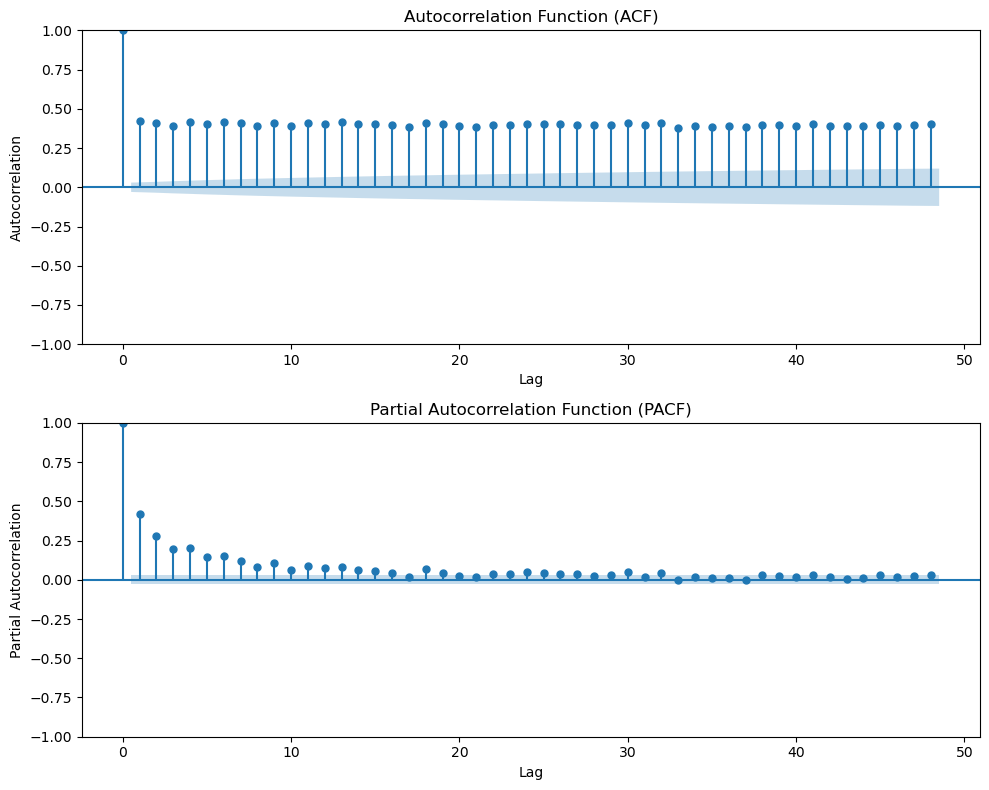

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8))

plot_acf(df_clean['total_power'], lags=48, ax=ax1)
ax1.set_title("Autocorrelation Function (ACF)")
ax1.set_xlabel("Lag")
ax1.set_ylabel("Autocorrelation")
plot_pacf(df_clean['total_power'], lags=48, ax=ax2)
ax2.set_title("Partial Autocorrelation Function (PACF)")
ax2.set_xlabel("Lag")
ax2.set_ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

In [12]:
jan = df_clean[df_clean.index.month == 1]
weekly_jan = jan.resample('W')['total_power'].mean()

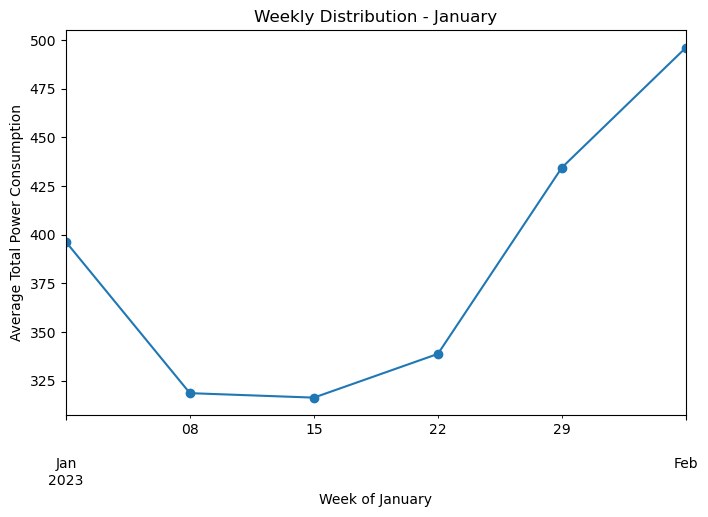

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
weekly_jan.plot(marker='o')
plt.title("Weekly Distribution - January")
plt.xlabel("Week of January")
plt.ylabel("Average Total Power Consumption")
plt.show()

In [14]:
jan_daily = jan.resample('D')['total_power'].mean().reset_index()
jan_daily['time_index'] = np.arange(len(jan_daily))

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

x = jan_daily[['time_index']]
y = jan_daily['total_power']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x) 

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

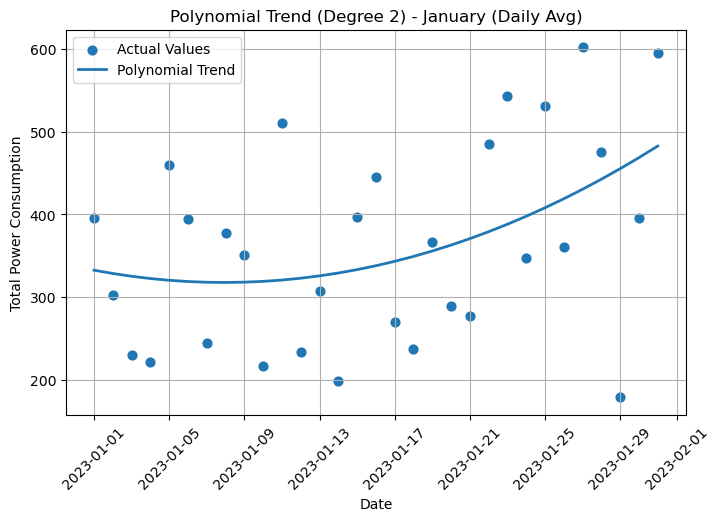

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(jan_daily['timestamp'], y, s=40, label="Actual Values")
plt.plot(jan_daily['timestamp'], y_pred, linewidth=2, label="Polynomial Trend")
plt.title("Polynomial Trend (Degree 2) - January (Daily Avg)")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [17]:
df_clean.index = pd.to_datetime(df_clean.index)
df_clean = df_clean.sort_index()

In [18]:
daily_df = df_clean.resample('D')[target_col].mean()
daily_df = daily_df.dropna()

In [19]:
def detect_cusum(x, drift_factor=0.25, threshold_factor=4):
    
    S_pos = np.zeros(len(x))
    S_neg = np.zeros(len(x))
    
    mu = np.mean(x)
    sigma = np.std(x)
    
    drift = drift_factor * sigma
    threshold = threshold_factor * sigma
    
    for i in range(1, len(x)):
        S_pos[i] = max(0, S_pos[i-1] + (x[i] - mu) - drift)
        S_neg[i] = max(0, S_neg[i-1] - (x[i] - mu) - drift)
    
    return S_pos, S_neg, threshold

C:\Users\louis\AppData\Local\Temp\ipykernel_17552\3422560368.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_groups = daily_df.groupby(pd.Grouper(freq='M'))


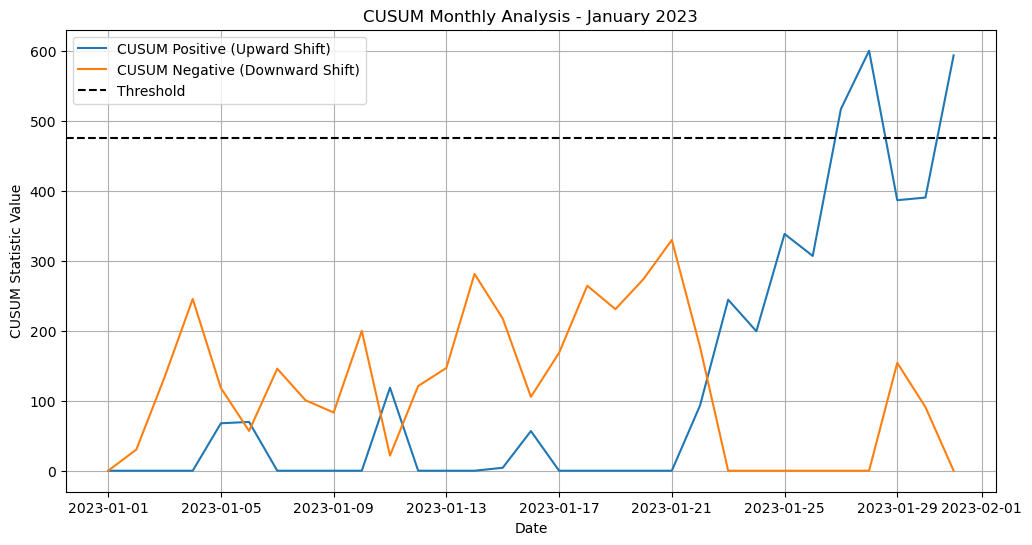

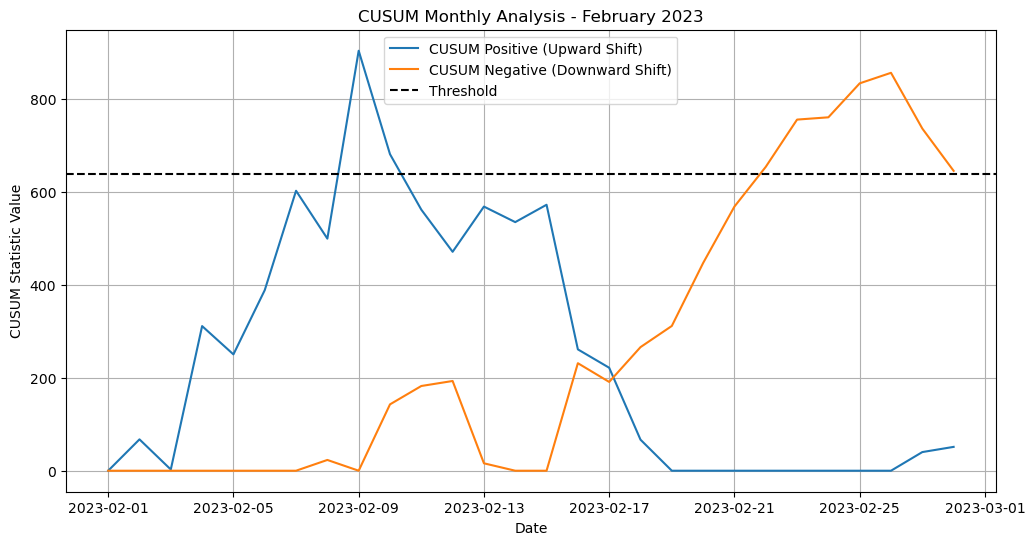

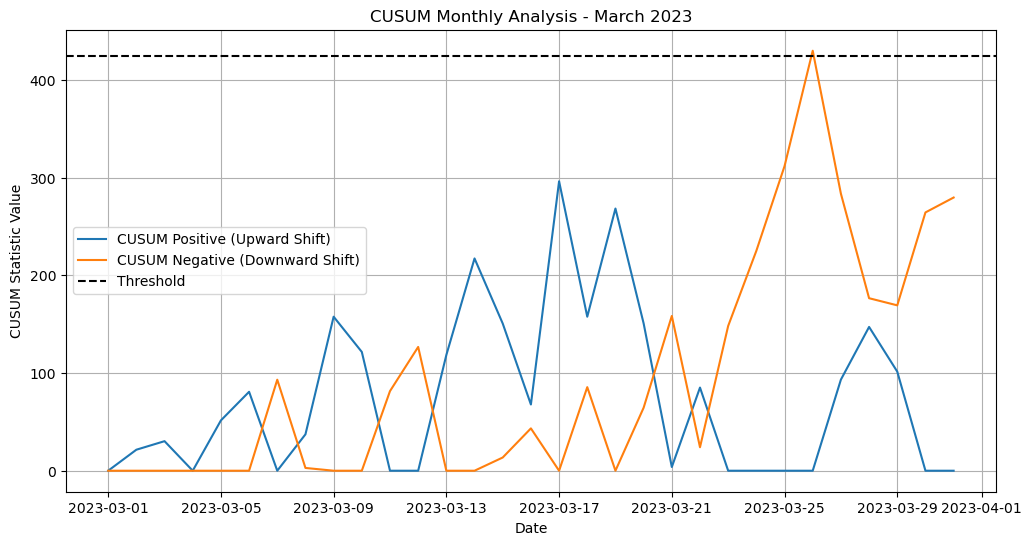

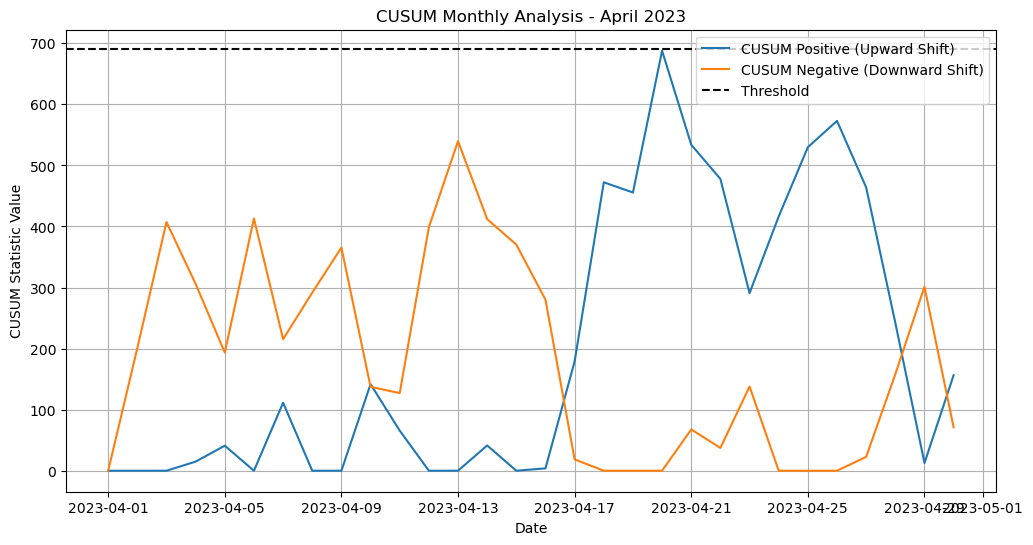

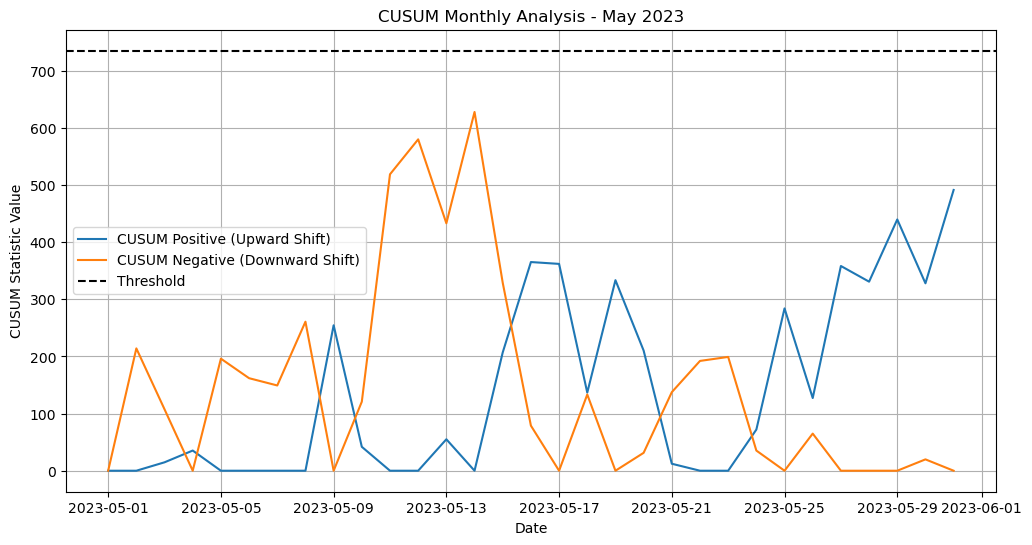

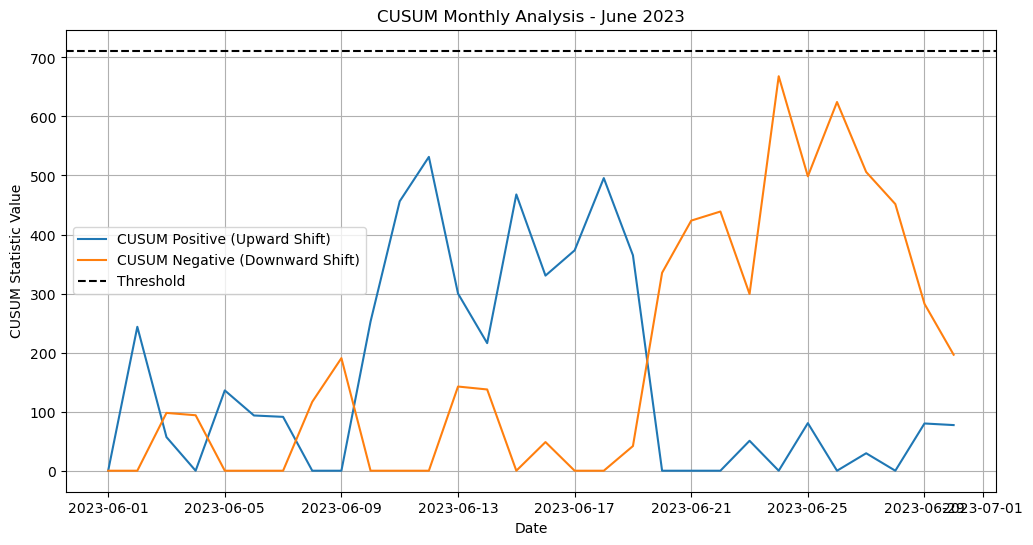

,Month,Upward Shift,Downward Shift
0,January 2023,True,False
1,February 2023,True,True
2,March 2023,False,True
3,April 2023,False,False
4,May 2023,False,False
5,June 2023,False,False


In [20]:
monthly_groups = daily_df.groupby(pd.Grouper(freq='M'))

summary = []

for month, group in monthly_groups:
    data = group.values
    if len(data) < 10:
        continue
    S_pos, S_neg, threshold = detect_cusum(data)
    plt.figure(figsize=(12,6))
    plt.plot(group.index, S_pos, label='CUSUM Positive (Upward Shift)')
    plt.plot(group.index, S_neg, label='CUSUM Negative (Downward Shift)')
    plt.axhline(threshold, linestyle='--', color='black', label='Threshold')
    plt.title(f"CUSUM Monthly Analysis - {month.strftime('%B %Y')}")
    plt.xlabel("Date")
    plt.ylabel("CUSUM Statistic Value")
    plt.legend()
    plt.grid(True)
    plt.show()
    upward_shift = np.any(S_pos > threshold)
    downward_shift = np.any(S_neg > threshold)
    summary.append({
        "Month": month.strftime('%B %Y'),
        "Upward Shift": upward_shift,
        "Downward Shift": downward_shift
    })
summary_df = pd.DataFrame(summary)
summary_df

ADF Statistic: -20.34600491406421
p-value: 0.0
Data is Stationary


D:\Anaconda\envs\py310\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


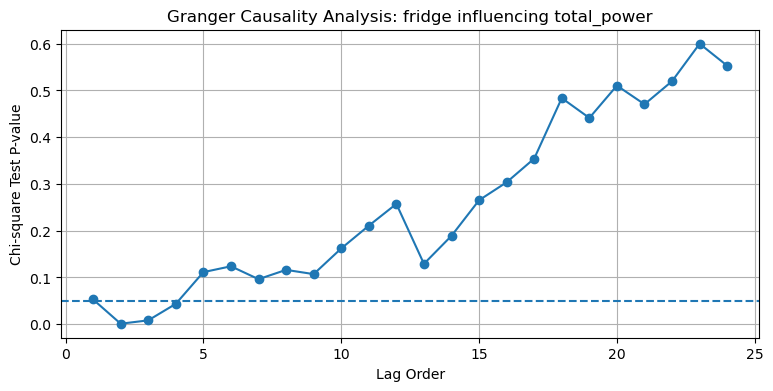

D:\Anaconda\envs\py310\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


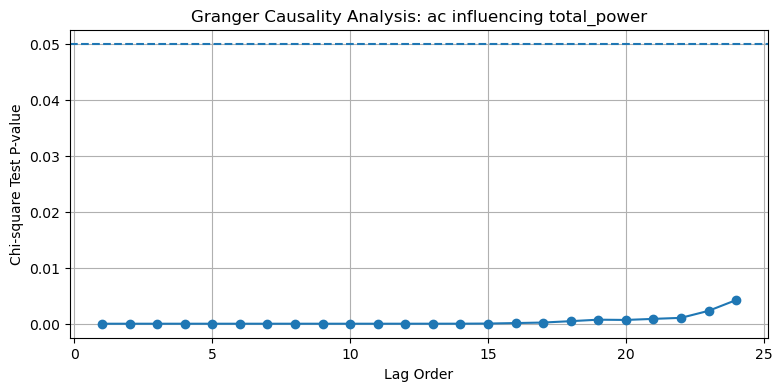

D:\Anaconda\envs\py310\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


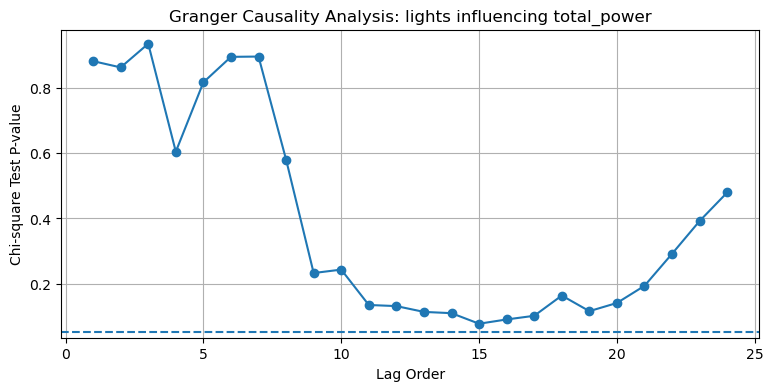

D:\Anaconda\envs\py310\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


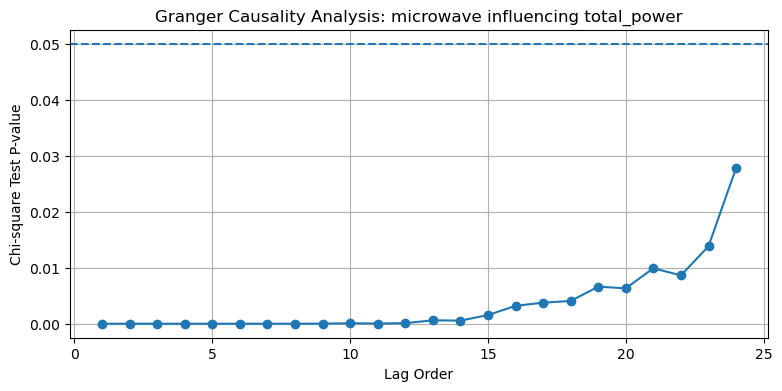

In [25]:
from statsmodels.tsa.stattools import grangercausalitytests

target_var = "total_power"
predictors = [c for c in df_clean.columns if c != target_var]
stationary_df = df_clean.diff().dropna()
_ = adf_test(stationary_df[target_var])
max_lag = 24

for predictor in predictors:
    pair_data = df_clean[[target_var, predictor]].dropna()
    test_output = grangercausalitytests(pair_data, maxlag=max_lag, verbose=False)

    lag_numbers = []
    p_vals = []

    for lag in range(1, max_lag + 1):
        lag_numbers.append(lag)
        p_vals.append(test_output[lag][0]['ssr_chi2test'][1])

    plt.figure(figsize=(9,4))
    plt.plot(lag_numbers, p_vals, marker='o')
    plt.axhline(y=0.05, linestyle='--')
    plt.title(f"Granger Causality Analysis: {predictor} influencing {target_var}")
    plt.xlabel("Lag Order")
    plt.ylabel("Chi-square Test P-value")
    plt.grid(True)
    plt.show()

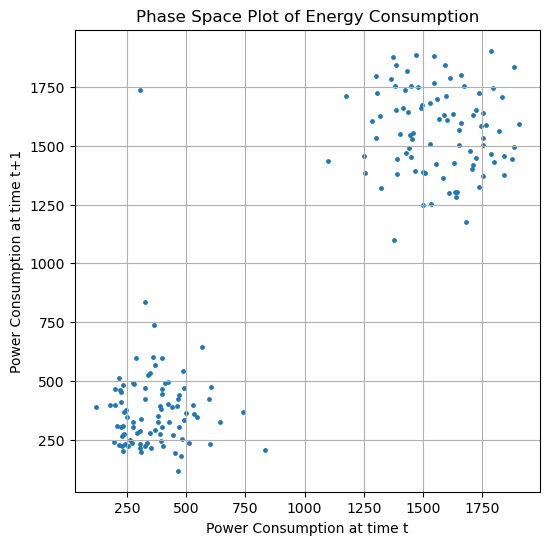

In [32]:
import numpy as np
import matplotlib.pyplot as plt
series = daily_df.values.flatten()
plt.figure(figsize=(6,6))
plt.scatter(series[:-1], series[1:], s=6)
plt.title("Phase Space Plot of Energy Consumption")
plt.xlabel("Power Consumption at time t")
plt.ylabel("Power Consumption at time t+1")
plt.grid(True)
plt.show()

In [36]:
series = daily_df.values.flatten()
# normalize the series
series = (series - np.mean(series)) / np.std(series)
# compute separation
distances = np.abs(np.diff(series))
# avoid zero values
distances = distances[distances > 0]
lyapunov_exp = np.mean(np.log(distances))
print("Estimated Lyapunov Exponent:", lyapunov_exp)

Estimated Lyapunov Exponent: -1.6315388367079546


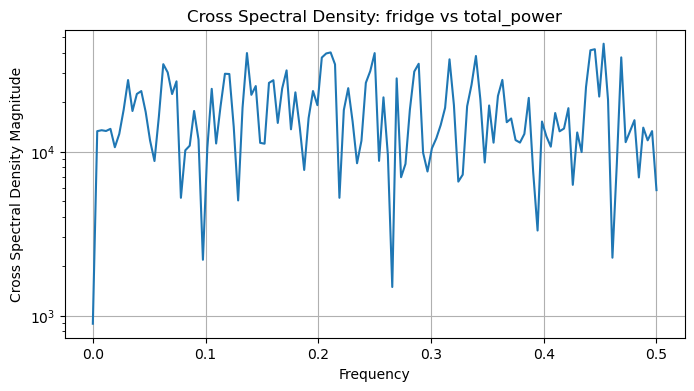

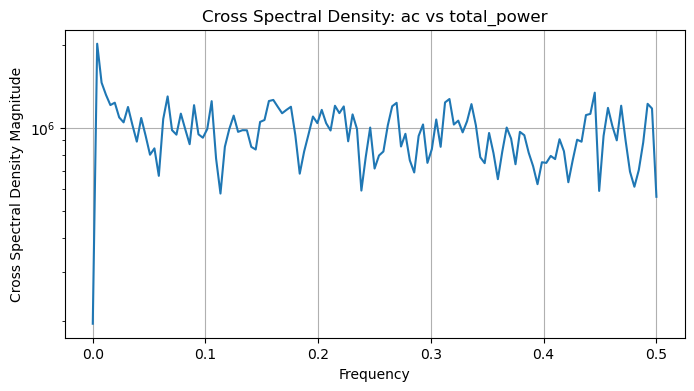

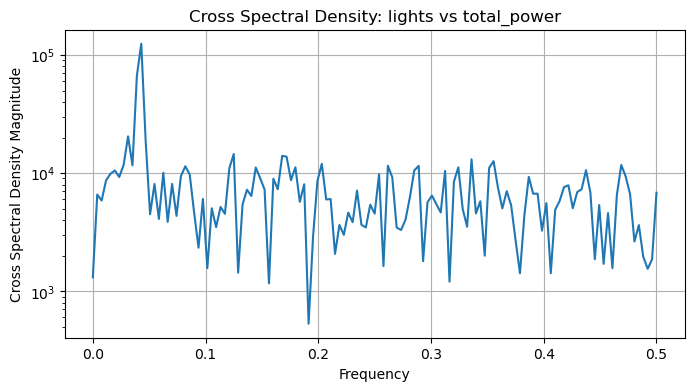

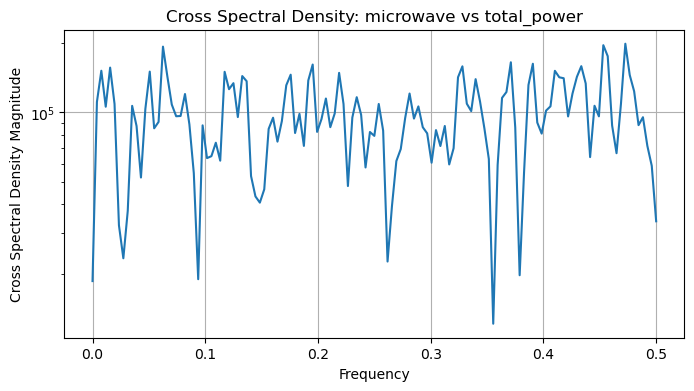

In [37]:
from scipy.signal import csd
import matplotlib.pyplot as plt
target = "total_power"
devices = [col for col in df_clean.columns if col != target]
for device in devices:
    x = df_clean[target].values
    y = df_clean[device].values
    # compute cross spectral density
    freq, Pxy = csd(x, y)
    plt.figure(figsize=(8,4))
    plt.semilogy(freq, abs(Pxy))
    plt.title(f"Cross Spectral Density: {device} vs {target}")
    plt.xlabel("Frequency")
    plt.ylabel("Cross Spectral Density Magnitude")
    plt.grid(True)
    plt.show()

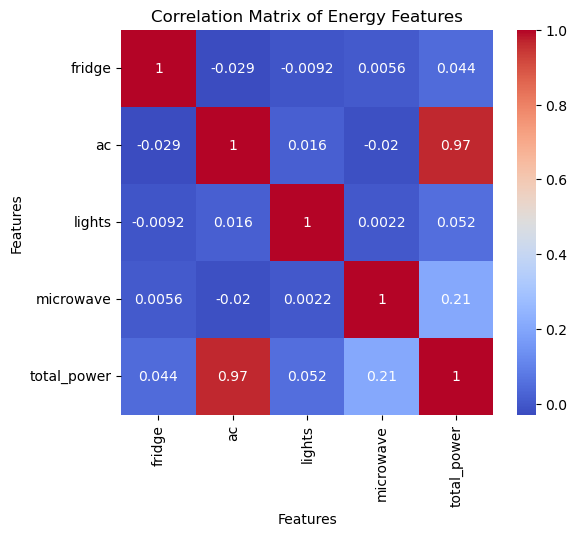

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
# correlation matrix
corr_matrix = df_clean.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Energy Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X = df_clean.drop(columns=["total_power"])
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

     Feature       VIF
0     fridge  1.611715
1         ac  1.438619
2     lights  1.500575
3  microwave  1.036707


In [6]:
from sklearn.feature_selection import mutual_info_regression
X = df_clean.drop(columns=["total_power"])
y = df_clean["total_power"]
mi_scores = mutual_info_regression(X, y)
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})
print(mi_df.sort_values(by="MI Score", ascending=False))

     Feature  MI Score
1         ac  1.420629
0     fridge  1.025338
2     lights  0.428295
3  microwave  0.109993


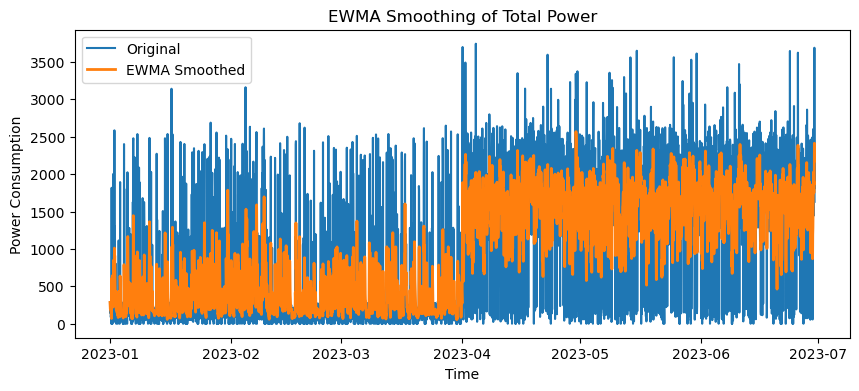

In [7]:
ewma_series = df_clean["total_power"].ewm(alpha=0.3).mean()
plt.figure(figsize=(10,4))
plt.plot(df_clean["total_power"], label="Original")
plt.plot(ewma_series, label="EWMA Smoothed", linewidth=2)
plt.title("EWMA Smoothing of Total Power")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.legend()
plt.show()